In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

In [45]:
# Load the data
df_quast = pd.read_csv('../data/transposed_report.tsv', sep = '\t')

In [49]:
# Define Thresholds
MIN_N50 = 20000        # 20kb
MAX_CONTIGS = 500      # 500 contigs
MIN_LEN = 4400000      # 4.4 Mb
MAX_LEN = 5000000      # 5.2 Mb (slightly relaxed upper bound to catch large plasmids/phages, Enteritidis is ~4.6-4.8)

In [51]:
# Determine Pass/Fail status
def check_qc(row):
    if (row['N50'] >= MIN_N50) and \
       (row['# contigs'] <= MAX_CONTIGS) and \
       (row['Total length'] >= MIN_LEN) and \
       (row['Total length'] <= MAX_LEN):
        return 'Pass'
    else:
        return 'Fail'

In [53]:
df_quast['QC_Status'] = df_quast.apply(check_qc, axis=1)

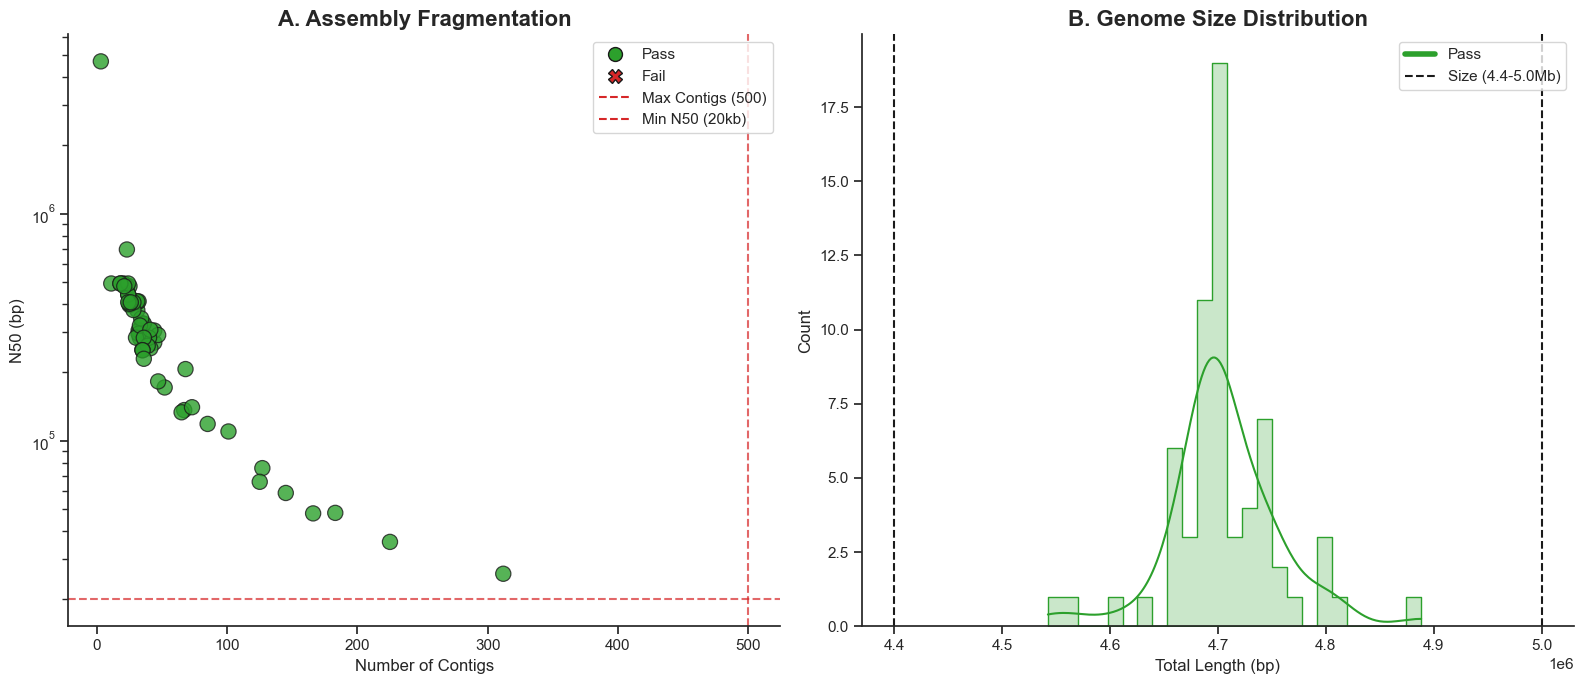

In [87]:
# Style
sns.set_style("ticks") # Clean look, no grid

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Panel A: Fragmentation ---
sns.scatterplot(
    data=df_quast, x='# contigs', y='N50', 
    hue='QC_Status', style='QC_Status',
    palette={'Pass': '#2ca02c', 'Fail': '#d62728'},
    s=120, alpha=0.8, edgecolor='k', ax=axes[0], legend=False
)

# Add Lines (for visual ref)
axes[0].axvline(MAX_CONTIGS, color='#d62728', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0].axhline(MIN_N50, color='#d62728', linestyle='--', linewidth=1.5, alpha=0.7)

# Custom Legend
legend_elements_a = [
    Line2D([0], [0], marker='o', color='w', label='Pass', markerfacecolor='#2ca02c', markersize=10, markeredgecolor='k'),
    Line2D([0], [0], marker='X', color='w', label='Fail', markerfacecolor='#d62728', markersize=10, markeredgecolor='k'),
    Line2D([0], [0], color='#d62728', linestyle='--', label=f'Max Contigs ({MAX_CONTIGS})'),
    Line2D([0], [0], color='#d62728', linestyle='--', label=f'Min N50 ({MIN_N50//1000}kb)')
]
axes[0].legend(handles=legend_elements_a, loc='upper right', frameon=True)
axes[0].set_yscale('log')
axes[0].set_title('A. Assembly Fragmentation', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Number of Contigs')
axes[0].set_ylabel('N50 (bp)')
sns.despine(ax=axes[0])

# --- Panel B: Size ---
sns.histplot(
    data=df_quast, x='Total length', hue='QC_Status', 
    palette={'Pass': '#2ca02c', 'Fail': '#d62728'},
    element='step', bins=25, kde=True, ax=axes[1], legend=False
)

axes[1].axvline(MIN_LEN, color='k', linestyle='--')
axes[1].axvline(MAX_LEN, color='k', linestyle='--')

legend_elements_b = [
    Line2D([0], [0], color='#2ca02c', lw=4, label='Pass'),
    Line2D([0], [0], color='k', linestyle='--', label=f'Size ({MIN_LEN/1e6}-{MAX_LEN/1e6}Mb)')
]
axes[1].legend(handles=legend_elements_b, loc='upper right')
axes[1].set_title('B. Genome Size Distribution', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Total Length (bp)')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('Figure_QC_metrics_clean.tiff', dpi=600, format='tiff')

In [ ]:
df_quast['QC_Status'] = df_quast.apply(check_qc, axis=1)